In [ ]:
# ============================================================
# FEEDFORWARD NEURAL NETWORKS (FFNN)
# Classification • Regression • Regularization • Tuning
# Prof. Olushina Olawale Awe
# Ready-to-run PyTorch script / notebook (all in one page)
# ============================================================

# If using Jupyter, you can run this as a single cell or split with # %% markers.

# %%
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

# ------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------
def accuracy(y_pred, y_true):
    """
    Binary accuracy for logits vs {0,1} labels.
    """
    y_hat = (torch.sigmoid(y_pred) > 0.5).float()
    return (y_hat == y_true).float().mean().item()

# SECTION A — CLASSIFICATION (make_moons)

In [ ]:
# Generate data
X, y = make_moons(n_samples=2000, noise=0.25, random_state=42)
y = y.reshape(-1, 1)

# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Convert to tensors
X_train = torch.tensor(X_train).float()
X_val   = torch.tensor(X_val).float()
X_test  = torch.tensor(X_test).float()

y_train = torch.tensor(y_train).float()
y_val   = torch.tensor(y_val).float()
y_test  = torch.tensor(y_test).float()

print("Train shapes:", X_train.shape, y_train.shape)
print("Val shapes:  ", X_val.shape, y_val.shape)
print("Test shapes: ", X_test.shape, y_test.shape)

Train shapes: torch.Size([1200, 2]) torch.Size([1200, 1])
Val shapes:   torch.Size([400, 2]) torch.Size([400, 1])
Test shapes:  torch.Size([400, 2]) torch.Size([400, 1])


In [ ]:
# How to know about the dataset
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      712 non-null    int64  
 1   age         712 non-null    float64
 2   sibsp       712 non-null    int64  
 3   parch       712 non-null    int64  
 4   fare        712 non-null    float64
 5   survived    712 non-null    int64  
 6   sex_male    712 non-null    bool   
 7   embarked_Q  712 non-null    bool   
 8   embarked_S  712 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 41.0 KB
None


In [3]:
# Load Titanic dataset
df = sns.load_dataset("titanic")

# Select useful features
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
df = df[features + ["survived"]].dropna()

# Convert categorical variables
df = pd.get_dummies(df, columns=["sex", "embarked"], drop_first=True)

# Split features and target
X = df.drop("survived", axis=1).values
y = df["survived"].values.reshape(-1, 1)

# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Convert to tensors
X_train = torch.tensor(X_train).float()
X_val   = torch.tensor(X_val).float()
X_test  = torch.tensor(X_test).float()

y_train = torch.tensor(y_train).float()
y_val   = torch.tensor(y_val).float()
y_test  = torch.tensor(y_test).float()

print("Train shapes:", X_train.shape, y_train.shape)
print("Val shapes:  ", X_val.shape, y_val.shape)
print("Test shapes: ", X_test.shape, y_test.shape)

Train shapes: torch.Size([427, 8]) torch.Size([427, 1])
Val shapes:   torch.Size([142, 8]) torch.Size([142, 1])
Test shapes:  torch.Size([143, 8]) torch.Size([143, 1])


# FFNN Classification Model

In [4]:
class FFNN(nn.Module):
    def __init__(self, in_dim=7, h1=16, h2=8, out_dim=1, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, out_dim)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.drop(x)
        x = self.relu(self.fc2(x))
        return self.fc3(x)   # logits

# Training function for classification

In [5]:
def train_classifier(model, lr=0.01, weight_decay=0.0, epochs=2000):
    """
    Train a binary classifier with BCEWithLogitsLoss.
    Uses global X_train, y_train, X_val, y_val.
    """
    criterion = nn.BCEWithLogitsLoss()
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []
    val_losses   = []

    for epoch in range(epochs):
        model.train()
        opt.zero_grad()
        logits = model(X_train)
        loss = criterion(logits, y_train)
        loss.backward()
        opt.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()
            val_losses.append(val_loss)

        if epoch % 200 == 0:
            acc_val = accuracy(val_logits, y_val)
            print(f"[Classifier] Epoch {epoch:4d} | Train Loss {loss.item():.4f} | Val Acc {acc_val:.4f}")

    return train_losses, val_losses

## A1 — Train baseline classifier

[Classifier] Epoch    0 | Train Loss 0.7071 | Val Acc 0.3803
[Classifier] Epoch  200 | Train Loss 0.6864 | Val Acc 0.4718
[Classifier] Epoch  400 | Train Loss 0.6578 | Val Acc 0.6408
[Classifier] Epoch  600 | Train Loss 0.6143 | Val Acc 0.6690
[Classifier] Epoch  800 | Train Loss 0.5684 | Val Acc 0.6901
[Classifier] Epoch 1000 | Train Loss 0.5316 | Val Acc 0.7394
[Classifier] Epoch 1200 | Train Loss 0.5001 | Val Acc 0.7606
[Classifier] Epoch 1400 | Train Loss 0.4746 | Val Acc 0.7887


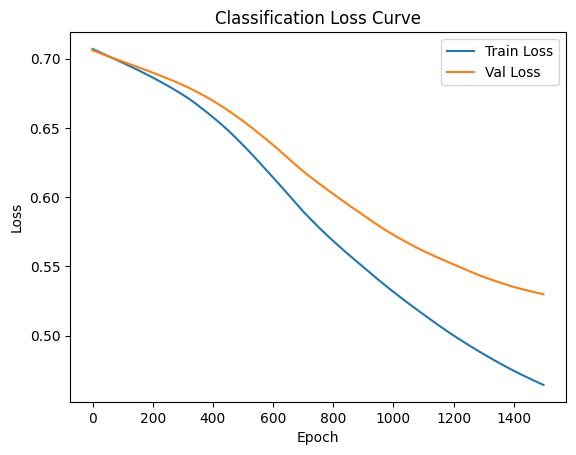


[Baseline] Test Accuracy: 0.7692307829856873


In [7]:
model = FFNN(in_dim=X_train.shape[1], dropout=0.0)
train_losses, val_losses = train_classifier(model, lr=1e-4, epochs=1500)

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Classification Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

model.eval()
with torch.no_grad():
    logits_test = model(X_test)
    test_acc = accuracy(logits_test, y_test)
print("\n[Baseline] Test Accuracy:", test_acc)

## A2 — Decision Boundary Visualization


Training FFNN for Titanic (2D PCA visualization)...
[Classifier] Epoch    0 | Train Loss 0.6681 | Val Acc 0.7254
[Classifier] Epoch  200 | Train Loss 0.6388 | Val Acc 0.6972
[Classifier] Epoch  400 | Train Loss 0.6098 | Val Acc 0.6901
[Classifier] Epoch  600 | Train Loss 0.5765 | Val Acc 0.6831
[Classifier] Epoch  800 | Train Loss 0.5492 | Val Acc 0.7042
Done.


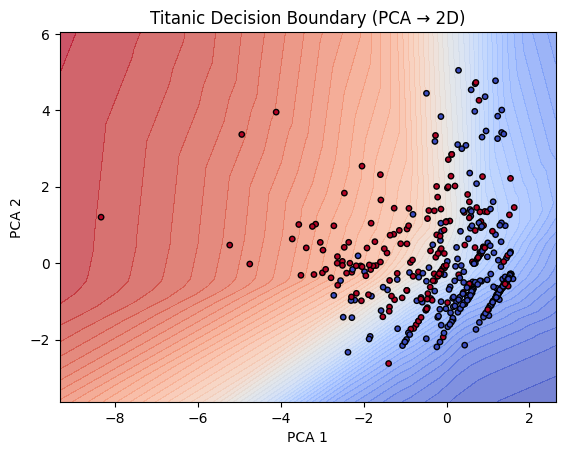

In [8]:
# ---- 1. Convert to numpy for PCA ----
X_train_np = X_train.cpu().numpy()
X_val_np   = X_val.cpu().numpy() # Need val data for scaling and PCA as well

# ---- 2. Scale (IMPORTANT for PCA) ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_val_scaled   = scaler.transform(X_val_np) # Use the same scaler fitted on train

# ---- 3. Reduce to 2D ----
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
X_val_2d   = pca.transform(X_val_scaled) # Use the same PCA fitted on train

# Convert back to torch
X_train_2d = torch.tensor(X_train_2d).float()
X_val_2d   = torch.tensor(X_val_2d).float()

# ===== Train a NEW model on 2D Titanic (PCA) =====
model_titanic_vis = FFNN(in_dim=2, dropout=0.0)

print("\nTraining FFNN for Titanic (2D PCA visualization)...")

# --- Temporarily swap global data for training ---
# Store original global tensors
_original_X_train = X_train
_original_y_train = y_train
_original_X_val = X_val
_original_y_val = y_val

# Replace global tensors with 2D PCA data for this specific training
X_train = X_train_2d
X_val   = X_val_2d
# y_train and y_val labels are still correct, no change needed for them.

train_losses, val_losses = train_classifier(model_titanic_vis, lr=1e-4, epochs=1000)

# --- Restore original global data after training ---
X_train = _original_X_train
y_train = _original_y_train
X_val   = _original_X_val
y_val   = _original_y_val

# Clean up temporary variables used for the swap
del _original_X_train, _original_y_train, _original_X_val, _original_y_val
del X_train_np, X_val_np, X_train_scaled, X_val_scaled, scaler, pca

print("Done.")

# ===== Decision boundary =====
# Use X_train_2d (which was derived from the original X_train) and its corresponding y_train for plotting

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()]).float()

model_titanic_vis.eval()
with torch.no_grad():
    zz = torch.sigmoid(model_titanic_vis(grid)).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, zz, levels=50, cmap="coolwarm", alpha=0.7)
plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train[:, 0], # Use the restored y_train which aligns with _original_X_train, and thus X_train_2d
    cmap="coolwarm",
    edgecolor="k",
    s=15
)

plt.title("Titanic Decision Boundary (PCA → 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

full Titanic 3D PCA + FFNN + decision surface visualization

Training Titanic 3D PCA model...
[Classifier] Epoch    0 | Train Loss 0.7809 | Val Acc 0.4225
[Classifier] Epoch  200 | Train Loss 0.7456 | Val Acc 0.4155
[Classifier] Epoch  400 | Train Loss 0.7169 | Val Acc 0.4507
[Classifier] Epoch  600 | Train Loss 0.6863 | Val Acc 0.4366
[Classifier] Epoch  800 | Train Loss 0.6474 | Val Acc 0.6479
Done.


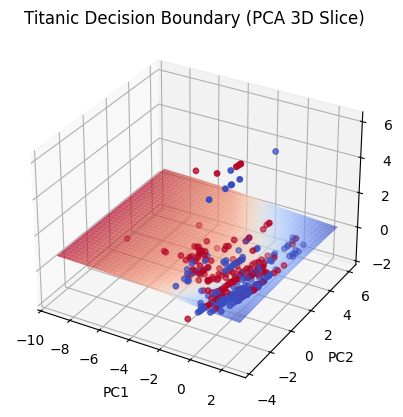

In [9]:
# ===== 1. Prepare Titanic data =====
# Ensure X_train and y_train are reset to the original 8-feature Titanic data
# in case they were modified by previous visualization cells.
# Reloading from df (which has 8 features) is the most robust way.
X = df.drop("survived", axis=1).values
y = df["survived"].values.reshape(-1, 1)

# Re-split for X_train, X_val to ensure consistent dimensions
X_train_full, X_temp_full, y_train_full, y_temp_full = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val_full, X_test_full, y_val_full, y_test_full = train_test_split(
    X_temp_full, y_temp_full, test_size=0.5, random_state=42
)

# Scale the full data before PCA
scaler_full = StandardScaler()
X_train_scaled_full = scaler_full.fit_transform(X_train_full)
X_val_scaled_full   = scaler_full.transform(X_val_full)

X_np = X_train_scaled_full # Now X_np is 8-feature and scaled
X_val_np = X_val_scaled_full # Now X_val_np is 8-feature and scaled

# PCA → 3D
pca = PCA(n_components=3)
X_3d = pca.fit_transform(X_np)
X_val_3d = pca.transform(X_val_np) # Apply same PCA to val data

X_3d = torch.tensor(X_3d).float()
y_3d = torch.tensor(y_train_full).float() # Use y_train_full corresponding to X_train_full
X_val_3d = torch.tensor(X_val_3d).float()
y_val_3d = torch.tensor(y_val_full).float() # Use y_val_full corresponding to X_val_full

# ===== 2. Train model =====
model_3d = FFNN(in_dim=3, dropout=0.0)

print("Training Titanic 3D PCA model...")

# --- Temporarily swap global data for training the 3D model ---
_original_X_train = X_train
_original_y_train = y_train
_original_X_val = X_val
_original_y_val = y_val

X_train = X_3d
y_train = y_3d
X_val = X_val_3d
y_val = y_val_3d

train_classifier(model_3d, lr=1e-4, epochs=1000)

# --- Restore original global data after training ---
X_train = _original_X_train
y_train = _original_y_train
X_val = _original_X_val
y_val = _original_y_val

del _original_X_train, _original_y_train, _original_X_val, _original_y_val
# Clean up temporary variables specific to this cell's data prep
del X_train_full, X_temp_full, y_train_full, y_temp_full, X_val_full, X_test_full, y_val_full, y_test_full
del scaler_full, X_train_scaled_full, X_val_scaled_full
del X_np, X_val_np, pca # Removed y_3d, X_val_3d, y_val_3d as they are still used below if not deleted before plot

print("Done.")

# ===== 3. Create 3D grid slice =====
model_3d.eval()

x_min, x_max = X_3d[:, 0].min() - 1, X_3d[:, 0].max() + 1
y_min, y_max = X_3d[:, 1].min() - 1, X_3d[:, 1].max() + 1
z_fixed = X_3d[:, 2].mean()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 80),
    np.linspace(y_min, y_max, 80)
)

grid = torch.tensor(
    np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, z_fixed)]
).float()

with torch.no_grad():
    zz = torch.sigmoid(model_3d(grid)).numpy().reshape(xx.shape)

# ===== 4. Plot 3D surface =====
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(xx, yy, zz, cmap="coolwarm", alpha=0.7)

ax.scatter(
    X_3d[:, 0],
    X_3d[:, 1],
    X_3d[:, 2],
    c=y_3d[:, 0], # Use y_3d (derived from y_train_full) for plotting the points
    cmap="coolwarm",
    s=15
)

ax.set_title("Titanic Decision Boundary (PCA 3D Slice)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()

# SECTION B — REGRESSION (sin curve)


Regression shapes: torch.Size([800, 1]) torch.Size([800, 1])
[Regressor] Epoch    0 | Loss 0.6595
[Regressor] Epoch  300 | Loss 0.0409
[Regressor] Epoch  600 | Loss 0.0134
[Regressor] Epoch  900 | Loss 0.0101
[Regressor] Epoch 1200 | Loss 0.0096


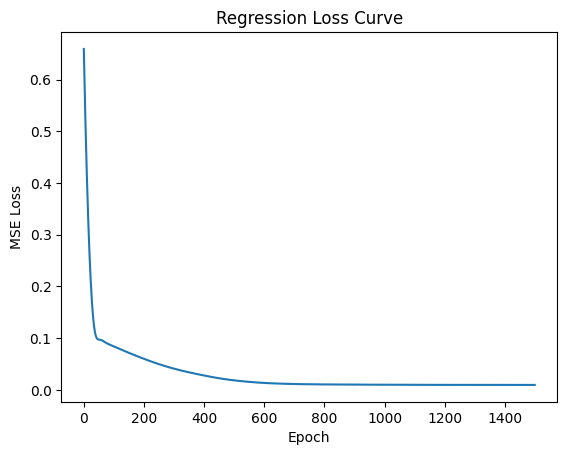

[Regressor] Test MSE: 0.00940800178796053


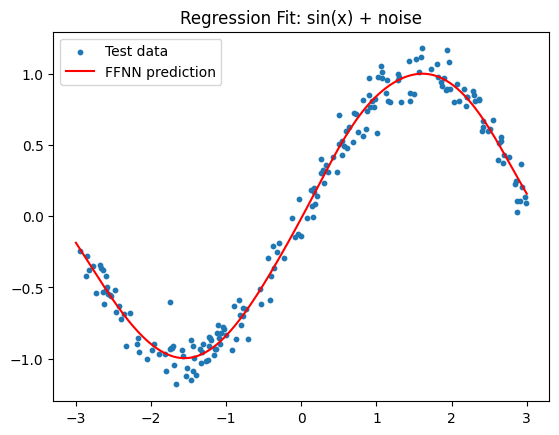

In [10]:
# Regression dataset
Xr = np.linspace(-3, 3, 1000).reshape(-1, 1)
yr = np.sin(Xr) + 0.1*np.random.randn(*Xr.shape)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=42
)

Xr_train = torch.tensor(Xr_train).float()
yr_train = torch.tensor(yr_train).float()

Xr_test = torch.tensor(Xr_test).float()
yr_test = torch.tensor(yr_test).float()

print("\nRegression shapes:", Xr_train.shape, yr_train.shape)

# Regression FFNN
class FFNN_Reg(nn.Module):
    def __init__(self): # Corrected from _init_ to __init__
        super().__init__()
        self.fc1 = nn.Linear(1, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        return self.fc3(x)

    # Hyperparameters for Adam
lr = 0.001                # learning rate
#betas = (0.9, 0.999)      # coefficients used for running averages
#eps = 1e-8                 # term added to improve numerical stability
#weight_decay = 1e-5        # L2 regularization
#amsgrad = False             # whether to use the AMSGrad variant

def train_regressor(model, lr=0.01, epochs=1500):
    criterion = nn.MSELoss()
    opt = optim.Adam(model.parameters(), lr=0.001)
    # Define the optimizer with all parameters
    #opt = optim.Adam(
    #    model.parameters(),
     #   lr=lr,
      #  betas=betas,
     #   eps=eps,
      #  weight_decay=weight_decay,
     #   amsgrad=amsgrad)

    losses = []

    for epoch in range(epochs):
        opt.zero_grad()
        pred = model(Xr_train)
        loss = criterion(pred, yr_train)
        loss.backward()
        opt.step()
        losses.append(loss.item())

        if epoch % 300 == 0:
            print(f"[Regressor] Epoch {epoch:4d} | Loss {loss.item():.4f}")

    return losses

reg = FFNN_Reg()
reg_losses = train_regressor(reg)

plt.figure()
plt.plot(reg_losses)
plt.title("Regression Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

reg.eval()
with torch.no_grad():
    pred_test = reg(Xr_test)
    mse_test = F.mse_loss(pred_test, yr_test).item()
print("[Regressor] Test MSE:", mse_test)

plt.figure()
plt.scatter(Xr_test, yr_test, s=10, label="Test data")
xgrid = np.linspace(-3, 3, 500).reshape(-1,1)
predgrid = reg(torch.tensor(xgrid).float()).detach().numpy()
plt.plot(xgrid, predgrid, color="red", label="FFNN prediction")
plt.legend()
plt.title("Regression Fit: sin(x) + noise")
plt.show()

# SECTION C — REGULARIZATION


[Weight Decay Experiment] WD = 0
[Classifier] Epoch    0 | Train Loss 0.6981 | Val Acc 0.4155
[Classifier] Epoch  200 | Train Loss 0.4016 | Val Acc 0.7817
[Classifier] Epoch  400 | Train Loss 0.3631 | Val Acc 0.8239
[Classifier] Epoch  600 | Train Loss 0.3399 | Val Acc 0.8099

[Weight Decay Experiment] WD = 1e-05
[Classifier] Epoch    0 | Train Loss 0.6734 | Val Acc 0.6268
[Classifier] Epoch  200 | Train Loss 0.3949 | Val Acc 0.7535
[Classifier] Epoch  400 | Train Loss 0.3516 | Val Acc 0.7817
[Classifier] Epoch  600 | Train Loss 0.3252 | Val Acc 0.7817

[Weight Decay Experiment] WD = 0.0001
[Classifier] Epoch    0 | Train Loss 0.6912 | Val Acc 0.5775
[Classifier] Epoch  200 | Train Loss 0.4139 | Val Acc 0.7958
[Classifier] Epoch  400 | Train Loss 0.3568 | Val Acc 0.7817
[Classifier] Epoch  600 | Train Loss 0.3306 | Val Acc 0.8169

[Weight Decay Experiment] WD = 0.001
[Classifier] Epoch    0 | Train Loss 0.7104 | Val Acc 0.4225
[Classifier] Epoch  200 | Train Loss 0.3948 | Val Acc 0.78

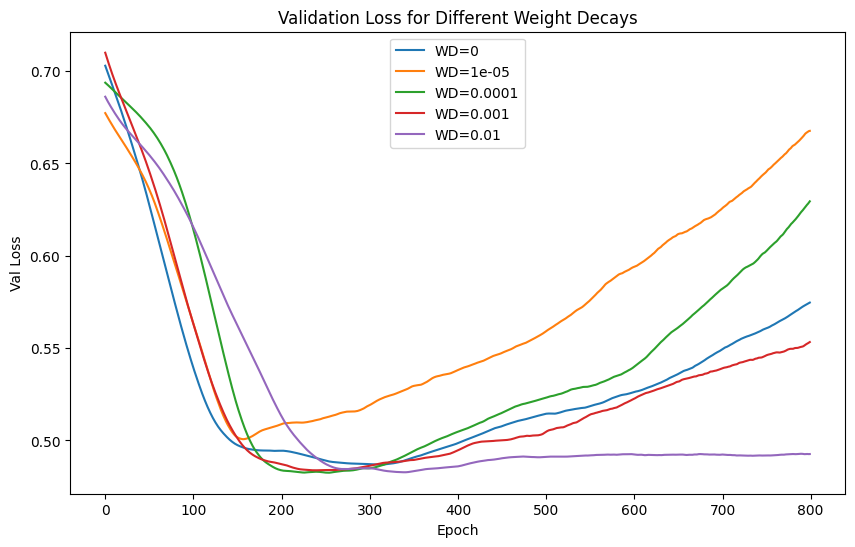


[Dropout Experiment] p = 0.0
[Classifier] Epoch    0 | Train Loss 0.6708 | Val Acc 0.5775
[Classifier] Epoch  200 | Train Loss 0.3920 | Val Acc 0.8239
[Classifier] Epoch  400 | Train Loss 0.3476 | Val Acc 0.7958
[Classifier] Epoch  600 | Train Loss 0.3185 | Val Acc 0.7817

[Dropout Experiment] p = 0.2
[Classifier] Epoch    0 | Train Loss 0.6794 | Val Acc 0.5775
[Classifier] Epoch  200 | Train Loss 0.4096 | Val Acc 0.7676
[Classifier] Epoch  400 | Train Loss 0.3975 | Val Acc 0.7958
[Classifier] Epoch  600 | Train Loss 0.3559 | Val Acc 0.8169

[Dropout Experiment] p = 0.5
[Classifier] Epoch    0 | Train Loss 0.6935 | Val Acc 0.4085
[Classifier] Epoch  200 | Train Loss 0.4744 | Val Acc 0.7817
[Classifier] Epoch  400 | Train Loss 0.4067 | Val Acc 0.7958
[Classifier] Epoch  600 | Train Loss 0.4326 | Val Acc 0.8169

[Dropout Experiment] p = 0.7
[Classifier] Epoch    0 | Train Loss 0.6968 | Val Acc 0.5563
[Classifier] Epoch  200 | Train Loss 0.5215 | Val Acc 0.7958
[Classifier] Epoch  400 | 

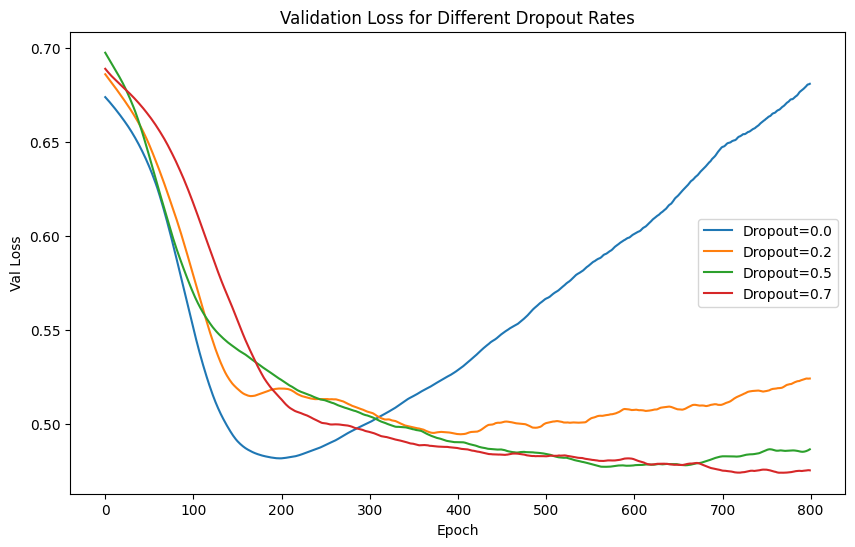

[EarlyStop] Epoch    0 | Val Loss 0.6850 | Patience 0
[EarlyStop] Epoch  100 | Val Loss 0.5724 | Patience 0
[EarlyStop] Epoch  200 | Val Loss 0.5183 | Patience 0
[EarlyStop] Epoch  300 | Val Loss 0.5132 | Patience 4
Early stopping at epoch 326


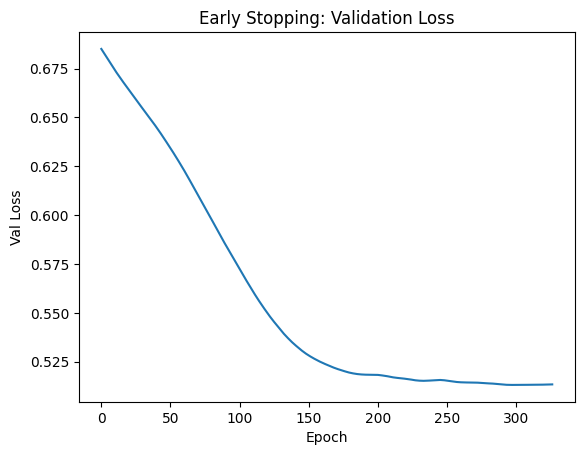

In [11]:
# C1 — L2 Weight Decay

# Explicitly load and prepare Titanic data for this section to avoid global variable issues
df_titanic = sns.load_dataset("titanic")
features_titanic = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
df_titanic = df_titanic[features_titanic + ["survived"]].dropna()
df_titanic = pd.get_dummies(df_titanic, columns=["sex", "embarked"], drop_first=True)

X_reg = df_titanic.drop("survived", axis=1).values
y_reg = df_titanic["survived"].values.reshape(-1, 1)

X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_reg, y_reg, test_size=0.4, random_state=42
)
X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg, y_temp_reg, test_size=0.5, random_state=42
)

scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_val_reg   = scaler_reg.transform(X_val_reg)
X_test_reg  = scaler_reg.transform(X_test_reg)

X_train_reg = torch.tensor(X_train_reg).float()
X_val_reg   = torch.tensor(X_val_reg).float()
X_test_reg  = torch.tensor(X_test_reg).float()
y_train_reg = torch.tensor(y_train_reg).float()
y_val_reg   = torch.tensor(y_val_reg).float()
y_test_reg  = torch.tensor(y_test_reg).float()

# Temporarily swap global X_train, y_train, X_val, y_val with regularization specific data
_original_X_train_global = X_train
_original_y_train_global = y_train
_original_X_val_global = X_val
_original_y_val_global = y_val

X_train = X_train_reg
y_train = y_train_reg
X_val = X_val_reg
y_val = y_val_reg

# Now proceed with experiments using the newly set up X_train, X_val (8 features)
decays = [0, 1e-5, 1e-4, 1e-3, 1e-2]
wd_results = {}

for wd in decays:
    print(f"\n[Weight Decay Experiment] WD = {wd}")
    model_wd = FFNN(in_dim=X_train.shape[1], dropout=0.0)
    tr_wd, vr_wd = train_classifier(model_wd, lr=1e-3, weight_decay=wd, epochs=800)
    wd_results[wd] = (tr_wd, vr_wd)

plt.figure(figsize=(10,6))
for wd in decays:
    plt.plot(wd_results[wd][1], label=f"WD={wd}")
plt.legend()
plt.title("Validation Loss for Different Weight Decays")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.show()

# C2 — Dropout
dropouts = [0.0, 0.2, 0.5, 0.7]
drop_results = {}

for p in dropouts:
    print(f"\n[Dropout Experiment] p = {p}")
    model_drop = FFNN(in_dim=X_train.shape[1], dropout=p)
    tr_d, vr_d = train_classifier(model_drop, lr=1e-3, epochs=800)
    drop_results[p] = (tr_d, vr_d)

plt.figure(figsize=(10,6))
for p in dropouts:
    plt.plot(drop_results[p][1], label=f"Dropout={p}")
plt.legend()
plt.title("Validation Loss for Different Dropout Rates")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.show()

# C3 — Early Stopping
def train_with_early_stopping(model, patience=30, lr=1e-3, epochs=2000):
    criterion = nn.BCEWithLogitsLoss()
    opt = optim.Adam(model.parameters(), lr=lr)

    best_loss = float("inf")
    counter = 0
    history = []

    for epoch in range(epochs):
        model.train()
        opt.zero_grad()
        logits = model(X_train)
        loss = criterion(logits, y_train)
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()

        history.append(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
        else:
            counter += 1

        if epoch % 100 == 0:
            print(f"[EarlyStop] Epoch {epoch:4d} | Val Loss {val_loss:.4f} | Patience {counter}")

        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    return history

model_es = FFNN(in_dim=X_train.shape[1])
es_history = train_with_early_stopping(model_es, patience=30, lr=1e-3, epochs=2000)

plt.figure()
plt.plot(es_history)
plt.title("Early Stopping: Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.show()

# Restore global X_train, y_train, X_val, y_val to their original state after the regularization experiments
X_train = _original_X_train_global
y_train = _original_y_train_global
X_val = _original_X_val_global
y_val = _original_y_val_global

# Clean up regularization-specific temporary variables
del df_titanic, features_titanic, X_reg, y_reg, X_train_reg, X_temp_reg, y_train_reg, y_temp_reg, \
    X_val_reg, X_test_reg, y_val_reg, y_test_reg, scaler_reg, _original_X_train_global, \
    _original_y_train_global, _original_X_val_global, _original_y_val_global

# SECTION D — HYPERPARAMETER TUNING


[Architecture Experiment] (8,)
[Classifier] Epoch    0 | Train Loss 0.7448 | Val Acc 0.4789
[Classifier] Epoch  200 | Train Loss 0.5222 | Val Acc 0.7817
[Classifier] Epoch  400 | Train Loss 0.4294 | Val Acc 0.8169
[Classifier] Epoch  600 | Train Loss 0.4029 | Val Acc 0.8099

[Architecture Experiment] (16,)
[Classifier] Epoch    0 | Train Loss 0.6517 | Val Acc 0.5775
[Classifier] Epoch  200 | Train Loss 0.4400 | Val Acc 0.8099
[Classifier] Epoch  400 | Train Loss 0.3832 | Val Acc 0.7817
[Classifier] Epoch  600 | Train Loss 0.3622 | Val Acc 0.7958

[Architecture Experiment] (32, 16)
[Classifier] Epoch    0 | Train Loss 0.7028 | Val Acc 0.4507
[Classifier] Epoch  200 | Train Loss 0.3667 | Val Acc 0.8169
[Classifier] Epoch  400 | Train Loss 0.3192 | Val Acc 0.7887
[Classifier] Epoch  600 | Train Loss 0.2706 | Val Acc 0.7676

[Architecture Experiment] (64, 32)
[Classifier] Epoch    0 | Train Loss 0.6674 | Val Acc 0.7676
[Classifier] Epoch  200 | Train Loss 0.3306 | Val Acc 0.7958
[Classifi

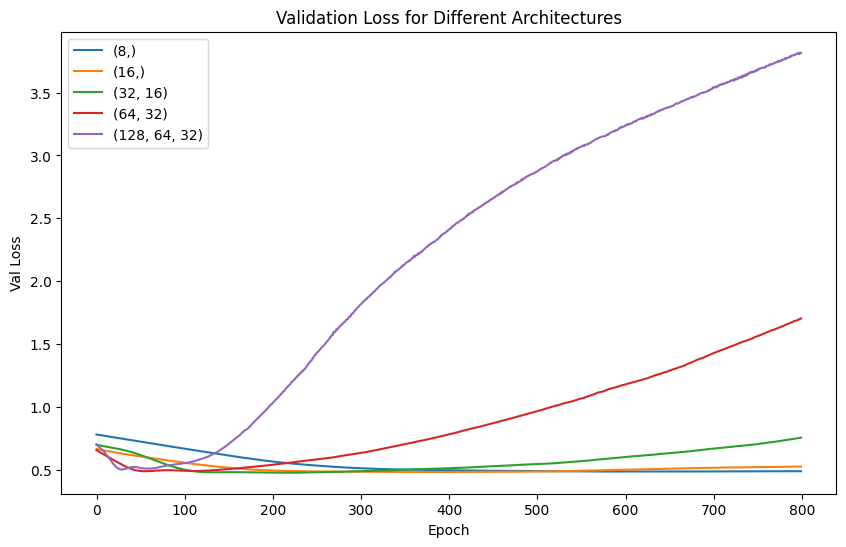


[LR Experiment] lr = 0.0001
[Classifier] Epoch    0 | Train Loss 0.6922 | Val Acc 0.5423
[Classifier] Epoch  200 | Train Loss 0.6697 | Val Acc 0.5915
[Classifier] Epoch  400 | Train Loss 0.6423 | Val Acc 0.6620

[LR Experiment] lr = 0.001
[Classifier] Epoch    0 | Train Loss 0.6999 | Val Acc 0.3732
[Classifier] Epoch  200 | Train Loss 0.4081 | Val Acc 0.7958
[Classifier] Epoch  400 | Train Loss 0.3643 | Val Acc 0.7887

[LR Experiment] lr = 0.01
[Classifier] Epoch    0 | Train Loss 0.6712 | Val Acc 0.5775
[Classifier] Epoch  200 | Train Loss 0.2243 | Val Acc 0.7394
[Classifier] Epoch  400 | Train Loss 0.1690 | Val Acc 0.7254

[LR Experiment] lr = 0.1
[Classifier] Epoch    0 | Train Loss 0.7111 | Val Acc 0.6690
[Classifier] Epoch  200 | Train Loss 0.1716 | Val Acc 0.7817
[Classifier] Epoch  400 | Train Loss 0.1364 | Val Acc 0.7887


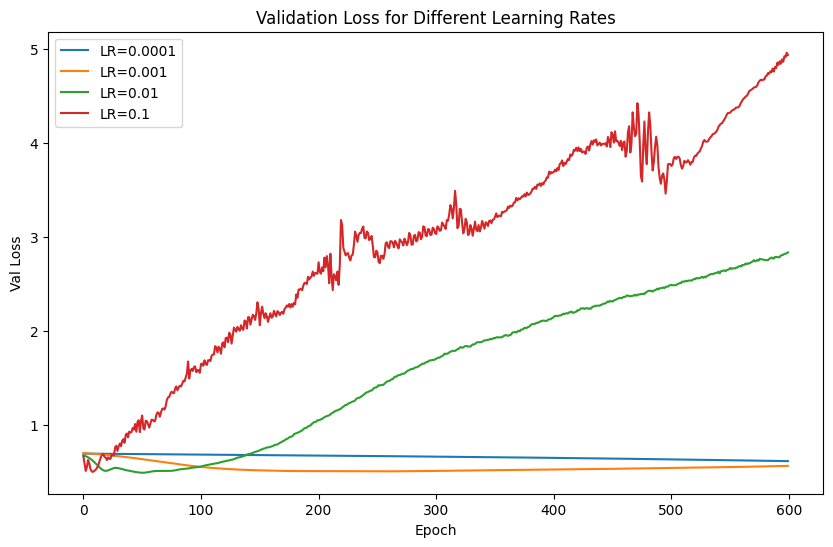


[Grid Search] WD=0, Dropout=0.0
[Classifier] Epoch    0 | Train Loss 0.7007 | Val Acc 0.2817
[Classifier] Epoch  200 | Train Loss 0.3995 | Val Acc 0.7606
[Classifier] Epoch  400 | Train Loss 0.3606 | Val Acc 0.7817

[Grid Search] WD=0, Dropout=0.2
[Classifier] Epoch    0 | Train Loss 0.6745 | Val Acc 0.6197
[Classifier] Epoch  200 | Train Loss 0.4185 | Val Acc 0.7817
[Classifier] Epoch  400 | Train Loss 0.3916 | Val Acc 0.8099

[Grid Search] WD=0, Dropout=0.5
[Classifier] Epoch    0 | Train Loss 0.6967 | Val Acc 0.4930
[Classifier] Epoch  200 | Train Loss 0.4542 | Val Acc 0.7817
[Classifier] Epoch  400 | Train Loss 0.4276 | Val Acc 0.8099

[Grid Search] WD=0.0001, Dropout=0.0
[Classifier] Epoch    0 | Train Loss 0.6585 | Val Acc 0.5775
[Classifier] Epoch  200 | Train Loss 0.3924 | Val Acc 0.7958
[Classifier] Epoch  400 | Train Loss 0.3433 | Val Acc 0.7887

[Grid Search] WD=0.0001, Dropout=0.2
[Classifier] Epoch    0 | Train Loss 0.6816 | Val Acc 0.5986
[Classifier] Epoch  200 | Train 

In [12]:
# D1 — Architecture Tuning
# Explicitly load and prepare Titanic data for this section to avoid global variable issues
df_titanic_tuning = sns.load_dataset("titanic")
features_titanic_tuning = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
df_titanic_tuning = df_titanic_tuning[features_titanic_tuning + ["survived"]].dropna()
df_titanic_tuning = pd.get_dummies(df_titanic_tuning, columns=["sex", "embarked"], drop_first=True)

X_tuning = df_titanic_tuning.drop("survived", axis=1).values
y_tuning = df_titanic_tuning["survived"].values.reshape(-1, 1)

X_train_tuning, X_temp_tuning, y_train_tuning, y_temp_tuning = train_test_split(
    X_tuning, y_tuning, test_size=0.4, random_state=42
)
X_val_tuning, X_test_tuning, y_val_tuning, y_test_tuning = train_test_split(
    X_temp_tuning, y_temp_tuning, test_size=0.5, random_state=42
)

scaler_tuning = StandardScaler()
X_train_tuning = scaler_tuning.fit_transform(X_train_tuning)
X_val_tuning   = scaler_tuning.transform(X_val_tuning)
X_test_tuning  = scaler_tuning.transform(X_test_tuning)

X_train_tuning = torch.tensor(X_train_tuning).float()
X_val_tuning   = torch.tensor(X_val_tuning).float()
X_test_tuning  = torch.tensor(X_test_tuning).float()
y_train_tuning = torch.tensor(y_train_tuning).float()
y_val_tuning   = torch.tensor(y_val_tuning).float()
y_test_tuning  = torch.tensor(y_test_tuning).float()

# Temporarily swap global X_train, y_train, X_val, y_val with tuning specific data
_original_X_train_global_tuning = X_train
_original_y_train_global_tuning = y_train
_original_X_val_global_tuning = X_val
_original_y_val_global_tuning = y_val

X_train = X_train_tuning
y_train = y_train_tuning
X_val = X_val_tuning
y_val = y_val_tuning

architectures = [
    (8,),
    (16,),
    (32, 16),
    (64, 32),
    (128, 64, 32)
]

arch_results = {}

for arch in architectures:
    print(f"\n[Architecture Experiment] {arch}")
    # Build network dynamically with nn.Sequential
    layers = []
    prev_dim = X_train.shape[1] # Dynamically set input dimension
    for h in arch:
        layers.append(nn.Linear(prev_dim, h))
        layers.append(nn.ReLU())
        prev_dim = h
    layers.append(nn.Linear(prev_dim, 1))
    model_arch = nn.Sequential(*layers)

    tr_arch, vr_arch = train_classifier(model_arch, lr=1e-3, epochs=800)
    arch_results[arch] = vr_arch

plt.figure(figsize=(10,6))
for arch in architectures:
    plt.plot(arch_results[arch], label=str(arch))
plt.legend()
plt.title("Validation Loss for Different Architectures")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.show()

# D2 — Learning Rate Tuning
lrs = [1e-4, 1e-3, 1e-2, 1e-1]
lr_results = {}

for lr in lrs:
    print(f"\n[LR Experiment] lr = {lr}")
    model_lr = FFNN(in_dim=X_train.shape[1]) # Dynamically set input dimension
    tr_lr, vr_lr = train_classifier(model_lr, lr=lr, epochs=600)
    lr_results[lr] = vr_lr

plt.figure(figsize=(10,6))
for lr in lrs:
    plt.plot(lr_results[lr], label=f"LR={lr}")
plt.legend()
plt.title("Validation Loss for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.show()

# D3 — Joint Tuning: Weight Decay × Dropout
grid_results = {}

for wd in [0, 1e-4, 1e-3]:
    for p in [0.0, 0.2, 0.5]:
        print(f"\n[Grid Search] WD={wd}, Dropout={p}")
        model_grid = FFNN(in_dim=X_train.shape[1], dropout=p) # Dynamically set input dimension
        tr_grid, vr_grid = train_classifier(model_grid, lr=1e-3, weight_decay=wd, epochs=600)
        # Store final validation loss
        grid_results[(wd, p)] = vr_grid[-1]

print("\nGrid Search Results (final validation loss):")
for (wd, p), vloss in grid_results.items():
    print(f"WD={wd}, Dropout={p} -> Val Loss={vloss:.4f}")

print("\nNotebook complete — ready for experiments!")

# Restore global X_train, y_train, X_val, y_val to their original state after the tuning experiments
X_train = _original_X_train_global_tuning
y_train = _original_y_train_global_tuning
X_val = _original_X_val_global_tuning
y_val = _original_y_val_global_tuning

# Clean up tuning-specific temporary variables
del df_titanic_tuning, features_titanic_tuning, X_tuning, y_tuning, X_train_tuning, X_temp_tuning, y_train_tuning, y_temp_tuning, \
    X_val_tuning, X_test_tuning, y_val_tuning, y_test_tuning, scaler_tuning, _original_X_train_global_tuning, \
    _original_y_train_global_tuning, _original_X_val_global_tuning, _original_y_val_global_tuning

Smaller models steadily improve, but the mid-sized architecture (32, 16) achieves the best validation accuracy (~83%), suggesting it captures the right level of complexity. Larger models keep reducing training loss but hurt validation accuracy, indicating overfitting beyond that point.

A moderate learning rate (0.001) gives the best and most stable validation accuracy (~81.7%), balancing convergence speed and generalization. Lower LR (0.0001) learns too slowly, while higher LRs (0.01, 0.1) converge fast but degrade performance due to instability/overshooting.

Moderate regularization improves generalization: the best performance comes from WD = 0.001 with low/moderate dropout (0.0–0.2), reaching the highest validation accuracy (~83%). Too much dropout (0.5) or no regularization at all tends to slightly hurt performance, indicating a balance is needed to avoid both under- and overfitting.